# 10 — Budget optimiser

**Purpose.** Convert uplift into money, and decide how to spend a fixed marketing
budget.

Feature 9 asked which campaign each customer should receive and answered it in
*visits*. No business has a visits budget. It has dollars, a cost per send, and a
margin on whatever revenue comes back — and those three numbers change the problem,
because they introduce something the visit analysis never had: **a reason not to
send.**

Three questions, in order.

1. **Does emailing pay for itself?** An email costs $0.10 and returns 30% of whatever
   incremental spend it causes. So it has to generate `0.10 / 0.30 = $0.33` of extra
   spend just to break even — a far more demanding bar than "the campaign has a
   positive effect", which is all Feature 4 established.
2. **Who gets dropped when the budget is short?** A fixed cost per send means a budget
   buys a fixed *number* of emails. Choosing whom to keep is a ranking problem, and
   Feature 8 already established which rankings can be trusted and which cannot.
3. **How sensitive is any of this to the two numbers nobody measured?** Margin and send
   cost are assumptions written into `config.py`, not data. A conclusion that flips
   between a 25% and a 35% margin is not a conclusion.

### Two structural choices

**Profit is a column, not a new estimator.** Realised profit per customer is
`margin × spend − cost × (they were emailed)`. Control customers carry no cost, so the
arm-minus-control difference in that column *is* incremental profit with the send cost
already netted out. Feature 4's Welch intervals and Feature 9's inverse propensity
weighting then apply unchanged — profit needs no new theory, only a new column.

**Greedy allocation is exactly optimal, not a heuristic.** Every email costs the same,
so "spend a budget to maximise profit" reduces to "pick the k best items", which greedy
solves exactly. The usual knapsack caveats apply only when item costs differ. The test
suite brute-forces this against every subset rather than leaving it as a claim.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import config
from src.data.load import load_processed
from src.models.budget import (
    run_budget_analysis, campaign_economics, break_even_uplift, with_profit,
    baseline_profit, greedy_allocation, evaluate_allocation, max_sends,
    best_arm_by_score, cross_fitted_arm_spend_uplifts, sensitivity_grid,
    NO_EMAIL, PROFIT_COLUMN,
)
from src.models.policy import policy_always, policy_difference

pd.set_option("display.width", 175)
df = load_processed()

MARGIN, COST = config.GROSS_MARGIN, config.COST_PER_EMAIL
print(f"Gross margin           : {MARGIN:.0%}")
print(f"Cost per email         : ${COST:.2f}")
print(f"Break-even spend uplift: ${break_even_uplift(MARGIN, COST):.4f}")
print(f"Cost of emailing all {len(df):,} customers: ${len(df) * COST:,.0f}")

Gross margin           : 30%
Cost per email         : $0.10
Break-even spend uplift: $0.3333
Cost of emailing all 64,000 customers: $6,400


## 1. Does each campaign pay for itself?

This is the question that actually has an answer in this dataset, so it goes first.

It needs no model and no targeting — just Feature 4's spend effect, converted into
money and compared against the break-even bar.

In [2]:
economics = pd.DataFrame([
    vars(e) | {"profitable": e.profitable, "headroom": e.margin_headroom}
    for e in campaign_economics(df, MARGIN, COST)
])

economics[[
    "treatment_arm", "spend_effect", "spend_ci_low", "spend_ci_high",
    "profit_per_email", "profit_ci_low", "profit_ci_high",
    "break_even_margin", "break_even_margin_high", "profitable",
]].style.format({
    "spend_effect": "${:.4f}",
    "spend_ci_low": "${:.4f}",
    "spend_ci_high": "${:.4f}",
    "profit_per_email": "${:+.4f}",
    "profit_ci_low": "${:+.4f}",
    "profit_ci_high": "${:+.4f}",
    "break_even_margin": "{:.1%}",
    "break_even_margin_high": "{:.1%}",
}).hide(axis="index")

treatment_arm,spend_effect,spend_ci_low,spend_ci_high,profit_per_email,profit_ci_low,profit_ci_high,break_even_margin,break_even_margin_high,profitable
Mens E-Mail,$0.7698,$0.4851,$1.0545,$+0.1309,$+0.0455,$+0.2164,13.0%,20.6%,True
Womens E-Mail,$0.4244,$0.1690,$0.6799,$+0.0273,$-0.0493,$+0.1040,23.6%,59.2%,False


**The Mens campaign pays for itself. The Womens campaign cannot be shown to.**

| | Mens E-Mail | Womens E-Mail |
|---|---|---|
| Profit per email | **+$0.131** | +$0.027 |
| 95% interval | [+$0.046, +$0.216] | [−$0.049, +$0.104] |
| Break-even margin | 13.0% | 23.6% |
| Break-even margin, worst case | **20.6%** | **59.2%** |

Both campaigns produced a statistically significant *spend* effect in Feature 4. Only
one of them clears the break-even bar with an interval that excludes zero. The
distinction matters: the Womens campaign lifts spend by $0.42, but it needs $0.33 to
pay for the send, and $0.42 ± $0.26 against a $0.33 threshold is not a decision.

The last row is the useful one for a planning conversation. **The Mens campaign stays
profitable down to a 20.6% gross margin even if its true effect sits at the pessimistic
end of the interval** — comfortable headroom against the assumed 30%. The Womens
campaign would need a 59.2% margin under the same pessimism, which is well above
anything assumed here. That asymmetry is what makes one of these a decision and the
other a coin flip.

## 2. How much do the assumptions carry?

Margin and send cost are assumptions. The honest presentation is the curve, not the
single cell.

In [3]:
margins = np.round(np.arange(0.10, 0.61, 0.05), 2)
grid = sensitivity_grid(df, margins=margins, costs=np.array([0.05, 0.10, 0.20]))

pivot = grid.pivot_table(
    index=["treatment_arm", "cost"], columns="margin", values="profitable"
)
pivot.style.format(lambda v: "yes" if v else "-").set_caption(
    "Is the campaign demonstrably profitable? (interval entirely above zero)"
)

The Mens campaign survives every cost/margin combination in the plausible range
except the most punitive. The Womens campaign is demonstrably profitable only when the
send is cheap *and* the margin is generous — it needs the assumptions to break its way.

Note that the break-even margin does not depend on the margin you assume. It is a
property of the spend effect and the send cost alone, which is why it is the right thing
to quote: it is the number that decides, rather than a number that follows from the
decision.

## 3. Does the optimiser work?

The real data's answer to "is targeting worth it" turns out to be largely "no", and a
broken optimiser would say the same thing. So, as with CUPED and uplift, the machinery
gets validated on data where the answer is known.

**Synthetic experiment:** 30% of customers are responders whose purchase probability
jumps when emailed; the rest are unaffected. Spend is gamma-distributed among buyers, so
the outcome keeps the zero-inflated heavy tail the real data has.

In [4]:
def synthetic_profit_experiment(n=30_000, seed=1):
    rng = np.random.default_rng(seed)
    responder = rng.random(n) < 0.3
    arm = rng.choice([config.CONTROL_ARM, config.MENS_ARM, config.WOMENS_ARM], size=n)

    emailed = arm != config.CONTROL_ARM
    bought = rng.binomial(1, np.where(responder & emailed, 0.25, 0.05))
    spend = bought * rng.gamma(shape=2.0, scale=30.0, size=n)

    return pd.DataFrame({
        "spend": spend, "visit": bought, "responder": responder.astype(float),
        config.TREATMENT_COL: pd.Categorical(
            arm, categories=[config.CONTROL_ARM, config.MENS_ARM, config.WOMENS_ARM]),
    })


synthetic = synthetic_profit_experiment()
synthetic_frame = with_profit(synthetic, MARGIN, COST)

uplifts_s = cross_fitted_arm_spend_uplifts(synthetic, features=["responder"])
columns_s = [f"spend_uplift_{a}" for a, _ in config.COMPARISONS]
arms_s, scores_s = best_arm_by_score(uplifts_s[columns_s])

n_sends = len(synthetic) // 3
reference_s = baseline_profit(synthetic_frame)
rng = np.random.default_rng(0)

targeted = evaluate_allocation(
    synthetic_frame, greedy_allocation(arms_s, scores_s, n_sends),
    "targeted", budget=n_sends * COST, baseline=reference_s)
untargeted = evaluate_allocation(
    synthetic_frame, greedy_allocation(arms_s, rng.random(len(synthetic)), n_sends),
    "random", budget=n_sends * COST, baseline=reference_s)

responder = synthetic["responder"].to_numpy().astype(bool)
chosen = greedy_allocation(arms_s, scores_s, n_sends) != NO_EMAIL

print(f"Budget covers {n_sends:,} of {len(synthetic):,} customers (one third)\n")
print(f"Share of the budget spent on true responders : {responder[chosen].mean():.1%}")
print(f"  (a random ranking would spend 30%)\n")
print(f"Net gain, ranked by predicted profit : ${targeted.net_gain:+,.0f}"
      f"   ({targeted.return_on_spend:.2f}x return)")
print(f"Net gain, random ranking             : ${untargeted.net_gain:+,.0f}"
      f"   ({untargeted.return_on_spend:.2f}x return)")

Budget covers 10,000 of 30,000 customers (one third)

Share of the budget spent on true responders : 90.4%
  (a random ranking would spend 30%)

Net gain, ranked by predicted profit : $+33,113   (33.11x return)
Net gain, random ranking             : $+10,176   (10.18x return)


The optimiser finds the responders and spends the constrained budget on them,
roughly tripling the return against a random ranking. **The machinery works.** Whatever
it reports on the real data is a fact about the data.

## 4. What a budget buys on the real experiment

Four ways to decide who gets emailed as the budget grows:

- **predicted profit** — arm and priority both from the spend model. The most direct
  answer, resting on the weakest model.
- **predicted visit uplift** — arm and priority from the visit model, which Feature 8
  showed is the only individual-level signal here that survives a null test. Ranking on
  a reliable proxy rather than an unreliable target.
- **always Mens** — the no-model baseline. Feature 9's recommendation, with customers
  dropped at random when the budget binds.
- **random ranking** — the null.

Every ranking shares one **eligibility** rule: a customer is emailed only if their
predicted incremental profit clears zero. Keeping eligibility (an economic question)
separate from priority (a ranking question) is deliberate — collapsing them would tie
every curve to the spend model.

In [5]:
results = run_budget_analysis(df, save=True)
curves, comparisons = results["curves"], results["comparisons"]
eligible = results["eligible"]

print(f"Baseline profit, emailing nobody : ${results['baseline_profit']:,.0f}")
print(f"Customers clearing break-even    : {eligible.sum():,} of {len(eligible):,} "
      f"({eligible.mean():.1%})\n")

full = curves[curves["budget"] == curves["budget"].max()]
full[["ranking", "n_sends", "cost_spent", "net_gain", "return_on_spend",
      "ci_low", "ci_high"]].style.format({
    "n_sends": "{:,}",
    "cost_spent": "${:,.0f}",
    "net_gain": "${:+,.0f}",
    "return_on_spend": "{:.2f}x",
    "ci_low": "{:+.4f}",
    "ci_high": "{:+.4f}",
}).hide(axis="index")

Baseline profit, emailing nobody : $12,534
Customers clearing break-even    : 54,881 of 64,000 (85.8%)



ranking,n_sends,cost_spent,net_gain,return_on_spend,ci_low,ci_high
predicted profit,"54,881","$5,488","$+5,716",1.04x,+0.2206,+0.3497
predicted visit uplift,"54,881","$5,488","$+9,532",1.74x,+0.2738,+0.4157
always Mens,"54,881","$5,488","$+8,857",1.61x,+0.2625,+0.4060
random ranking,"54,881","$5,488","$+5,716",1.04x,+0.2206,+0.3497


Two things to read carefully here.

**"predicted profit" and "random ranking" are identical, exactly.** That is not a bug,
it is a check. Priority order only matters while the budget binds; at a full-send budget
both select every eligible customer and assign the same arms, so they *must* coincide.
If they ever diverged at full budget the allocator would be doing something other than
what it claims. The test suite asserts it.

**The marginal intervals are useless for comparing rankings.** They are wide because
profit inherits spend's heavy tail — 99% of customers spend nothing and a handful spend
hundreds. Comparing two overlapping intervals here would conclude nothing about
anything. Feature 9's answer applies: compare the policies **paired**.

## 5. Which ranking should spend the budget?

In [6]:
n = len(df)
comparisons.assign(total_dollars=comparisons["difference"] * n)[[
    "ranking", "versus", "total_dollars", "difference", "ci_low", "ci_high",
    "p_value", "n_disagree",
]].style.format({
    "total_dollars": "${:+,.0f}",
    "difference": "{:+.4f}",
    "ci_low": "{:+.4f}",
    "ci_high": "{:+.4f}",
    "p_value": "{:.3f}",
    "n_disagree": "{:,}",
}).hide(axis="index")

ranking,versus,total_dollars,difference,ci_low,ci_high,p_value,n_disagree
predicted profit,always Mens,"$-3,140",-0.0491,-0.0944,-0.0038,0.034,"13,850"
predicted visit uplift,always Mens,$+675,+0.0105,-0.0347,+0.0558,0.648,"16,910"
random ranking,always Mens,"$-3,140",-0.0491,-0.0944,-0.0038,0.034,"13,850"


**Ranking on the spend model is significantly worse than using no model at all.**

−$3,140 against "always Mens", p = 0.034. This is the sharpest result in the feature,
and Feature 8 predicted it: spend uplift failed its null test, so its rankings are
noise, and acting on noise is not neutral — it reassigns 13,850 customers away from the
campaign that actually works and costs real money.

It is worth being precise about *why* it loses. The spend model does not merely fail to
add value; it overrides a correct default. Feature 4 established that Mens beats Womens
on spend by roughly 2:1. Wherever the noisy model prefers Womens, it is trading a known
effect for a spurious one.

**Ranking on visit uplift is indistinguishable from no model at all.** +$675, p = 0.65.
That is exactly Feature 9's finding carried into dollars: directionally fine, far below
what this experiment can resolve.

The pattern across the two is the useful lesson. A model that passes a null test is
harmless when used for targeting even if it adds nothing measurable. A model that fails
one is actively expensive. **The cost of deploying an unvalidated uplift model is not
zero.**

## 6. Is the eligibility gate worth anything?

The gate withholds email from 9,119 customers whose predicted incremental profit is
negative — saving $912 in send cost. But the gate rests on the same spend model that
just failed. Does it help?

In [7]:
frame = with_profit(df, MARGIN, COST)
ungated = policy_always(config.MENS_ARM, n)
gated = np.where(eligible, config.MENS_ARM, NO_EMAIL).astype(object)

gate = policy_difference(frame, gated, ungated, PROFIT_COLUMN)

print(f"Emails withheld : {(~eligible).sum():,}   "
      f"send cost saved: ${(~eligible).sum() * COST:,.0f}")
print(f"Profit effect   : ${gate['difference'] * n:+,.0f}  "
      f"[{gate['ci_low'] * n:+,.0f}, {gate['ci_high'] * n:+,.0f}]  "
      f"p = {gate['p_value']:.3f}")

Emails withheld : 9,119   send cost saved: $912
Profit effect   : $+476  [-1,051, +2,004]  p = 0.541


The gate saves $912 of certain cost and returns $476 of profit that the interval
cannot separate from zero. So it neither helps nor hurts measurably.

That is a genuinely awkward result to report and worth stating plainly: **the case for
withholding rests on the cost saving, which is certain, and not on the revenue effect,
which is unresolved.** A gate built on a model that failed its null test should not be
credited with revenue it cannot demonstrate.

## 7. Chart

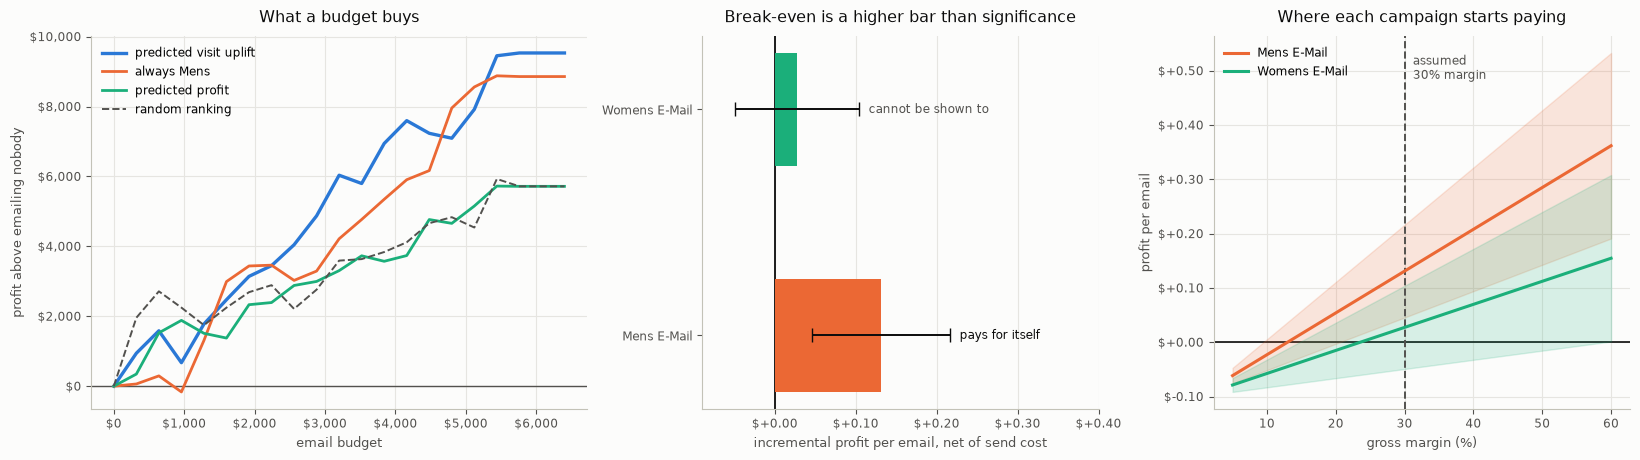

In [8]:
SURFACE, INK, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e6e5e1"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"

RANKING_STYLE = {
    "predicted visit uplift": (BLUE, "-", 2.4),
    "always Mens": (ORANGE, "-", 2.0),
    "predicted profit": (AQUA, "-", 2.0),
    "random ranking": (MUTED, "--", 1.4),
}

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.7),
                         gridspec_kw={"width_ratios": [1.25, 1, 1.05]})
fig.patch.set_facecolor(SURFACE)

# --- Panel 1: what a budget buys -----------------------------------------------
ax = axes[0]
ax.set_facecolor(SURFACE)
for ranking, (colour, style, width) in RANKING_STYLE.items():
    rows = curves[curves["ranking"] == ranking].sort_values("budget")
    ax.plot(rows["budget"], rows["net_gain"], color=colour, linestyle=style,
            linewidth=width, zorder=4, label=ranking)

ax.axhline(0, color=MUTED, linewidth=1.0, zorder=2)
ax.set_xlabel("email budget", fontsize=9, color=MUTED)
ax.set_ylabel("profit above emailing nobody", fontsize=9, color=MUTED)
ax.set_title("What a budget buys", fontsize=11.5, color=INK, pad=10)
ax.xaxis.set_major_formatter(lambda v, _: f"${v:,.0f}")
ax.yaxis.set_major_formatter(lambda v, _: f"${v:,.0f}")
ax.legend(frameon=False, fontsize=8.5, loc="upper left")
ax.grid(color=GRID, linewidth=0.8, zorder=0)

# --- Panel 2: does each campaign pay for itself? -------------------------------
ax = axes[1]
ax.set_facecolor(SURFACE)
positions = np.arange(len(economics))
colours = [ORANGE if a == config.MENS_ARM else AQUA
           for a in economics["treatment_arm"]]

ax.barh(positions, economics["profit_per_email"], color=colours, height=0.5, zorder=3)
ax.errorbar(economics["profit_per_email"], positions,
            xerr=[economics["profit_per_email"] - economics["profit_ci_low"],
                  economics["profit_ci_high"] - economics["profit_per_email"]],
            fmt="none", ecolor=INK, elinewidth=1.4, capsize=5, zorder=4)
ax.axvline(0, color=INK, linewidth=1.3, zorder=2)

for y, row in zip(positions, economics.itertuples()):
    verdict = "pays for itself" if row.profitable else "cannot be shown to"
    ax.text(row.profit_ci_high + 0.012, y, verdict, va="center", fontsize=8.5,
            color=INK if row.profitable else MUTED)

ax.set_yticks(positions)
ax.set_yticklabels(economics["treatment_arm"], fontsize=9, color=INK)
ax.set_xlim(-0.09, 0.40)
ax.set_xlabel("incremental profit per email, net of send cost",
              fontsize=9, color=MUTED)
ax.set_title("Break-even is a higher bar than significance",
             fontsize=11.5, color=INK, pad=10)
ax.xaxis.set_major_formatter(lambda v, _: f"${v:+.2f}")
ax.grid(axis="x", color=GRID, linewidth=0.8, zorder=0)

# --- Panel 3: how much do the assumptions carry? -------------------------------
ax = axes[2]
ax.set_facecolor(SURFACE)
fine = sensitivity_grid(df, margins=np.linspace(0.05, 0.60, 34),
                        costs=np.array([COST]))

for arm, colour in [(config.MENS_ARM, ORANGE), (config.WOMENS_ARM, AQUA)]:
    rows = fine[fine["treatment_arm"] == arm].sort_values("margin")
    ax.plot(rows["margin"] * 100, rows["profit_per_email"], color=colour,
            linewidth=2.2, zorder=4, label=arm)
    ax.fill_between(rows["margin"] * 100, rows["profit_ci_low"],
                    rows["profit_ci_high"], color=colour, alpha=0.16, zorder=3)

ax.axhline(0, color=INK, linewidth=1.2, zorder=2)
ax.axvline(MARGIN * 100, color=MUTED, linewidth=1.4, linestyle="--", zorder=3)
ax.text(MARGIN * 100 + 1.2, ax.get_ylim()[1] * 0.86, "assumed\n30% margin",
        fontsize=8.5, color=MUTED)

ax.set_xlabel("gross margin (%)", fontsize=9, color=MUTED)
ax.set_ylabel("profit per email", fontsize=9, color=MUTED)
ax.set_title("Where each campaign starts paying", fontsize=11.5, color=INK, pad=10)
ax.yaxis.set_major_formatter(lambda v, _: f"${v:+.2f}")
ax.legend(frameon=False, fontsize=8.5, loc="upper left")
ax.grid(color=GRID, linewidth=0.8, zorder=0)

for ax in axes:
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color("#c3c2b7")
    ax.tick_params(colors=MUTED, labelsize=8.5)

fig.tight_layout()

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "10_budget_optimiser.png", dpi=150, bbox_inches="tight",
            facecolor=SURFACE)
plt.show()

The left panel is the one to be careful with. Below about $1,500 the curves cross
each other repeatedly and the random ranking is briefly the best of the four — a clear
signal that at those budgets the differences are noise, since a random ranking cannot
genuinely be the best way to spend money. Reading a winner off the eye is exactly the
mistake the paired comparison in section 5 exists to prevent; the visible gap at full
send is a hypothesis for that test, not a result.

What the panel *does* establish on its own is that spending more beats spending less all
the way to a full send. No curve turns over, so there is no budget level at which this
file is saturated.

## Conclusions

| Question | Answer |
|---|---|
| Does Mens E-Mail pay for itself? | **Yes** — +$0.131/email, CI [+$0.046, +$0.216] |
| Does Womens E-Mail? | **Cannot be shown** — CI [−$0.049, +$0.104] |
| How safe is the 30% margin assumption? | Mens works down to 20.6% even pessimistically; Womens needs 59.2% |
| Best use of a budget | Send Mens, spend to the limit — 1.74x return at a full send |
| Does ranking by the spend model help? | **No — it costs $3,140** (p = 0.034) |
| Does ranking by visit uplift help? | Not measurably (+$675, p = 0.65) |
| Is withholding worth it? | Only for the certain $912 cost saving |

**The recommendation.** Send the Mens campaign to as many customers as the budget
covers. Every dollar of email budget returns about $1.74 of incremental profit at the
configured assumptions, there is no budget level at which that stops being true within
this file, and no ranking tested improves on spending it uniformly.

**The methodological result is the more transferable one.** Two uplift models were built
on the same data with the same code. The one that passed its null test (visit) is
harmless in deployment — it adds nothing measurable but costs nothing. The one that
failed (spend) is not neutral: routing the budget by it loses $3,140, because it
overrides a default that Feature 4 had already established was correct. *The cost of
deploying an unvalidated model is not zero*, and the null test in Feature 8 is what
separates the two cases.

**What would change the answer.** The break-even bar is $0.33 of incremental spend
against a Womens effect of $0.42 ± $0.26. Narrowing that interval enough to decide
whether the Womens campaign is worth sending is a far smaller ask than the 1.4 million
customers Feature 9 needed for personalisation — it is the one open question here that a
realistically-sized follow-up experiment could actually close.

**Next — Feature 11:** a Streamlit dashboard over the DuckDB warehouse, with margin and
send cost as live inputs, so the profit conclusion can be stress-tested by whoever is
making the decision rather than only by whoever ran the analysis.